<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
# (!nvidia-smi only works on machines with an NVIDIA driver, so check with PyTorch instead)
import torch
print(f"CUDA GPU available: {torch.cuda.is_available()}")

CUDA GPU available: False


In [2]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.14.0+cpu


'cpu'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

**Trả lời:** ba cách khắc phục underfitting (mô hình chưa học đủ tốt, loss trên cả train và test đều cao):

1. **Tăng độ phức tạp của mô hình**: thêm layer hoặc tăng số hidden units để mô hình có đủ "sức chứa" học được các mẫu phức tạp trong dữ liệu.
2. **Huấn luyện lâu hơn**: tăng số epoch (hoặc điều chỉnh learning rate cho phù hợp) để mô hình có thêm thời gian cập nhật trọng số và hội tụ tới nghiệm tốt hơn.
3. **Dùng transfer learning**: tận dụng một mô hình đã được huấn luyện sẵn trên tập dữ liệu lớn (ví dụ ImageNet), các đặc trưng đã học sẵn giúp mô hình đạt kết quả tốt ngay cả khi dữ liệu của mình ít.

(Ngoài ra: giảm regularization quá mạnh – ví dụ bớt dropout, đưa thêm đặc trưng/dữ liệu tốt hơn vào mô hình.)

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [3]:
# 1. Get data
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
  print(f"{image_path} directory exists.")
else:
  print(f"Did not find {image_path} directory, creating one...")
  image_path.mkdir(parents=True, exist_ok=True)

  # Download pizza, steak, sushi data
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

  # Unzip pizza, steak, sushi data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data...")
    zip_ref.extractall(image_path)

Did not find data\pizza_steak_sushi directory, creating one...


Unzipping pizza, steak, sushi data...


In [4]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.


There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [5]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

Random image path: data\pizza_steak_sushi\test\sushi\2394442.jpg
Image class: sushi
Image height: 408
Image width: 512


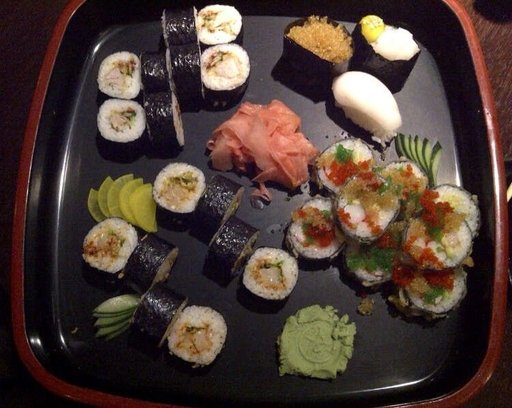

In [6]:
# Visualize an image
import random
from PIL import Image

random.seed(42)

# 1. Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

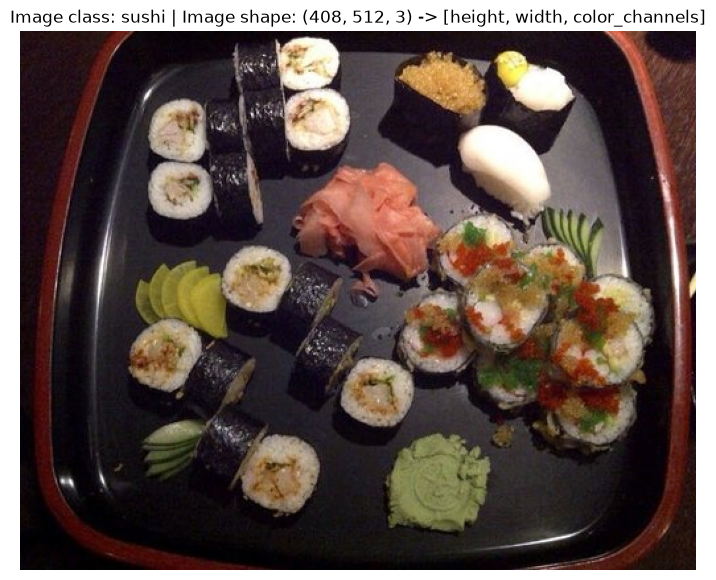

In [7]:
# Do the image visualization with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [8]:
# 3.1 Transforming data with torchvision.transforms
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [9]:
# Write transform for turning images into tensors
data_transform = transforms.Compose([
  # Resize the images to 64x64x3 (64 height, 64 width, 3 color channels)
  transforms.Resize(size=(64, 64)),
  # Flip the images randomly on horizontal
  transforms.RandomHorizontalFlip(p=0.5),
  # Turn the image into a torch.Tensor (also converts pixel values from 0-255 to 0.0-1.0)
  transforms.ToTensor()
])

data_transform(img).shape

torch.Size([3, 64, 64])

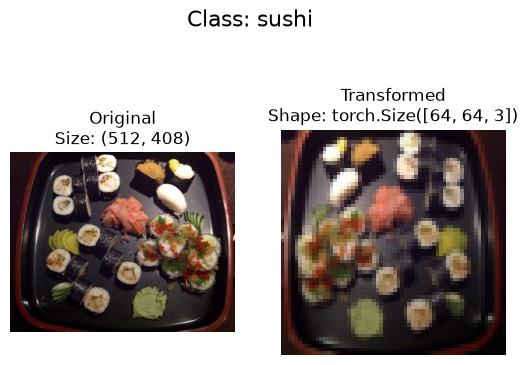

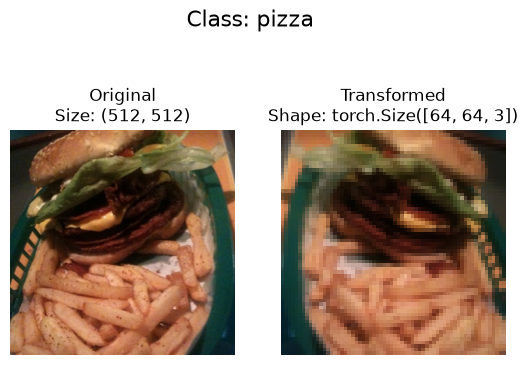

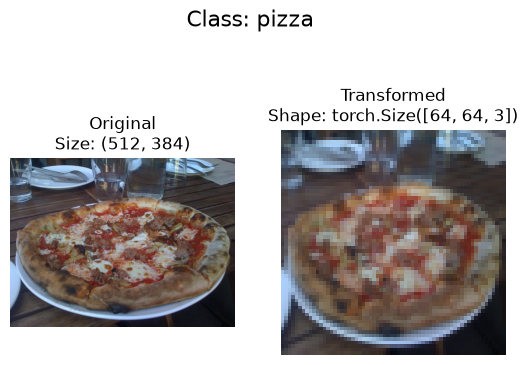

In [10]:
# Write a function to plot transformed images
def plot_transformed_images(image_paths, transform, n=3, seed=42):
  """Plots a series of random images from image_paths (original vs transformed)."""
  random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1, 2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      # Note: permute() changes shape for matplotlib (C, H, W) -> (H, W, C)
      transformed_image = transform(f).permute(1, 2, 0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, transform=data_transform, n=3)

### Load image data using `ImageFolder`

In [11]:
# Use ImageFolder to create dataset(s)
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # a transform for the data
                                  target_transform=None) # a transform for the label/target

# No random flipping on the test data (augmentation is only for training)
test_transform = transforms.Compose([
  transforms.Resize(size=(64, 64)),
  transforms.ToTensor()
])

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=test_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [12]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [13]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [14]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [15]:
# Turn train and test Datasets into DataLoaders
# num_workers=0 loads data in the main process (avoids the process start-up cost on Windows)
BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x215c265ae40>,
 <torch.utils.data.dataloader.DataLoader at 0x215c2b0f110>)

In [16]:
# How many batches of images are in our data loaders?
len(train_dataloader), len(test_dataloader)

(8, 3)

## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [17]:
class TinyVGG(nn.Module):
  """Model architecture copying TinyVGG from CNN Explainer: https://poloclub.github.io/cnn-explainer/"""
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) # default stride value is same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        # 64 -> 62 -> 60 -> pool 30 -> 28 -> 26 -> pool 13, so the output is hidden_units*13*13
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [18]:
# Try a forward pass on a single image to test the model
img_batch, label_batch = next(iter(train_dataloader))
model_0.eval()
with torch.inference_mode():
  pred = model_0(img_batch.to(device))
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_batch}")

Output logits:
tensor([[ 2.0673e-02, -1.8577e-03,  1.0150e-02],
        [ 1.9347e-02,  3.1597e-03,  7.4475e-03],
        [ 1.8337e-02,  1.9958e-03,  8.1829e-03],
        [ 2.1068e-02, -2.6110e-03,  1.0277e-02],
        [ 2.1972e-02,  1.9002e-04,  1.0116e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 1.9515e-02, -1.1101e-03,  1.2304e-02],
        [ 1.8869e-02, -2.3141e-03,  9.5120e-03],
        [ 2.5152e-02, -4.1530e-03,  1.2133e-02],
        [ 2.0239e-02, -4.7978e-04,  1.0907e-02],
        [ 1.9972e-02, -2.9622e-03,  8.2557e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.2784e-02, -2.9035e-03,  9.9879e-03],
        [ 1.9760e-02, -2.7160e-04,  9.8396e-03],
        [ 2.1635e-02, -4.3994e-03,  9.4989e-03],
        [ 2.2589e-02, -3.4084e-03,  1.0640e-02],
        [ 2.0182e-02, -2.1775e-03,  9.5757e-03],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 2.1306e-02, -9.6528e-04,  1.0207e-02],
        [ 1.9073e-02, -9.2566e-05,  9.4177e-03],
     

## 4. Create training and testing functions for `model_0`.

In [19]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumualte accuracy metric across all batches
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and average accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [20]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. Calculuate and accumulate loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate and accumulate accuracy
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [21]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model, 
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    
    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer. 

In [22]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:02<00:08,  2.08s/it]

Epoch: 1 | train_loss: 1.1063 | train_acc: 0.3125 | test_loss: 1.0988 | test_acc: 0.2396


 40%|████      | 2/5 [00:04<00:06,  2.23s/it]

Epoch: 2 | train_loss: 1.1043 | train_acc: 0.3008 | test_loss: 1.0624 | test_acc: 0.5417


...

 80%|████████  | 4/5 [00:08<00:01,  1.98s/it]

Epoch: 4 | train_loss: 1.0870 | train_acc: 0.4258 | test_loss: 1.1050 | test_acc: 0.2604


100%|██████████| 5/5 [00:09<00:00,  1.90s/it]

100%|██████████| 5/5 [00:09<00:00,  1.98s/it]

Epoch: 5 | train_loss: 1.0555 | train_acc: 0.4961 | test_loss: 1.0431 | test_acc: 0.4432


In [23]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:01<00:35,  1.87s/it]

Epoch: 1 | train_loss: 1.1063 | train_acc: 0.3125 | test_loss: 1.0988 | test_acc: 0.2396


 10%|█         | 2/20 [00:04<00:39,  2.19s/it]

Epoch: 2 | train_loss: 1.1043 | train_acc: 0.3008 | test_loss: 1.0624 | test_acc: 0.5417


...

 95%|█████████▌| 19/20 [00:37<00:01,  1.99s/it]

Epoch: 19 | train_loss: 0.7426 | train_acc: 0.6875 | test_loss: 1.1567 | test_acc: 0.4242


100%|██████████| 20/20 [00:39<00:00,  2.05s/it]

100%|██████████| 20/20 [00:39<00:00,  1.98s/it]

Epoch: 20 | train_loss: 0.7742 | train_acc: 0.6719 | test_loss: 1.0733 | test_acc: 0.3939


In [24]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_2 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(),
                             lr=0.001)

model_2_results = train(model=model_2,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=50)

  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:02<02:11,  2.68s/it]

Epoch: 1 | train_loss: 1.1063 | train_acc: 0.3125 | test_loss: 1.0988 | test_acc: 0.2396


  4%|▍         | 2/50 [00:05<02:02,  2.55s/it]

Epoch: 2 | train_loss: 1.1043 | train_acc: 0.3008 | test_loss: 1.0624 | test_acc: 0.5417


...

 98%|█████████▊| 49/50 [01:46<00:01,  1.86s/it]

Epoch: 49 | train_loss: 0.8291 | train_acc: 0.6367 | test_loss: 1.2112 | test_acc: 0.4754


100%|██████████| 50/50 [01:48<00:00,  1.82s/it]

100%|██████████| 50/50 [01:48<00:00,  2.16s/it]

Epoch: 50 | train_loss: 0.6254 | train_acc: 0.7539 | test_loss: 1.0996 | test_acc: 0.5152


,train_loss,train_acc,test_loss,test_acc
5 epochs,1.055534,0.496094,1.043150,0.443182
20 epochs,0.774246,0.671875,1.073287,0.393939
50 epochs,0.625419,0.753906,1.099590,0.515152


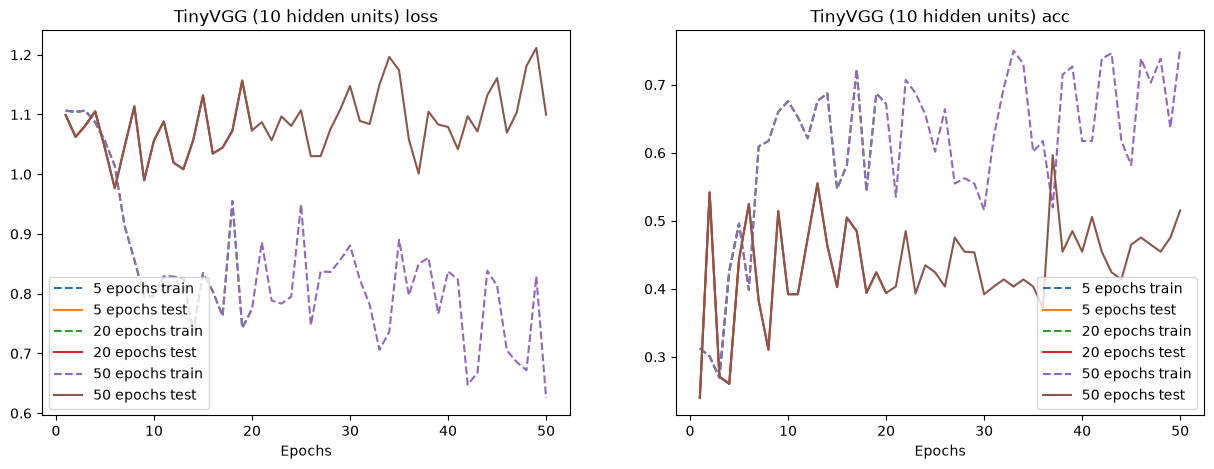

In [25]:
# Plot the loss curves of the 3 runs to compare them
import pandas as pd

def plot_results(results_dict, title=""):
  """Plots train/test loss & accuracy curves for several result dicts."""
  plt.figure(figsize=(15, 5))
  for i, metric in enumerate(["loss", "acc"]):
    plt.subplot(1, 2, i+1)
    for name, results in results_dict.items():
      epochs_range = range(1, len(results[f"train_{metric}"]) + 1)
      plt.plot(epochs_range, results[f"train_{metric}"], label=f"{name} train", linestyle="--")
      plt.plot(epochs_range, results[f"test_{metric}"], label=f"{name} test")
    plt.title(f"{title} {metric}")
    plt.xlabel("Epochs")
    plt.legend()

plot_results({"5 epochs": model_0_results,
              "20 epochs": model_1_results,
              "50 epochs": model_2_results}, title="TinyVGG (10 hidden units)")

# Final metrics of each run
pd.DataFrame({name: {k: v[-1] for k, v in r.items()}
              for name, r in {"5 epochs": model_0_results,
                              "20 epochs": model_1_results,
                              "50 epochs": model_2_results}.items()}).T

It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:01<00:36,  1.92s/it]

Epoch: 1 | train_loss: 1.1040 | train_acc: 0.2500 | test_loss: 1.1012 | test_acc: 0.1979


 10%|█         | 2/20 [00:04<00:39,  2.21s/it]

Epoch: 2 | train_loss: 1.0949 | train_acc: 0.4297 | test_loss: 1.1101 | test_acc: 0.1979


...

 95%|█████████▌| 19/20 [00:41<00:02,  2.65s/it]

Epoch: 19 | train_loss: 0.7707 | train_acc: 0.6758 | test_loss: 1.0384 | test_acc: 0.4754


100%|██████████| 20/20 [00:44<00:00,  2.62s/it]

100%|██████████| 20/20 [00:44<00:00,  2.22s/it]

Epoch: 20 | train_loss: 0.7362 | train_acc: 0.7227 | test_loss: 1.0715 | test_acc: 0.4848


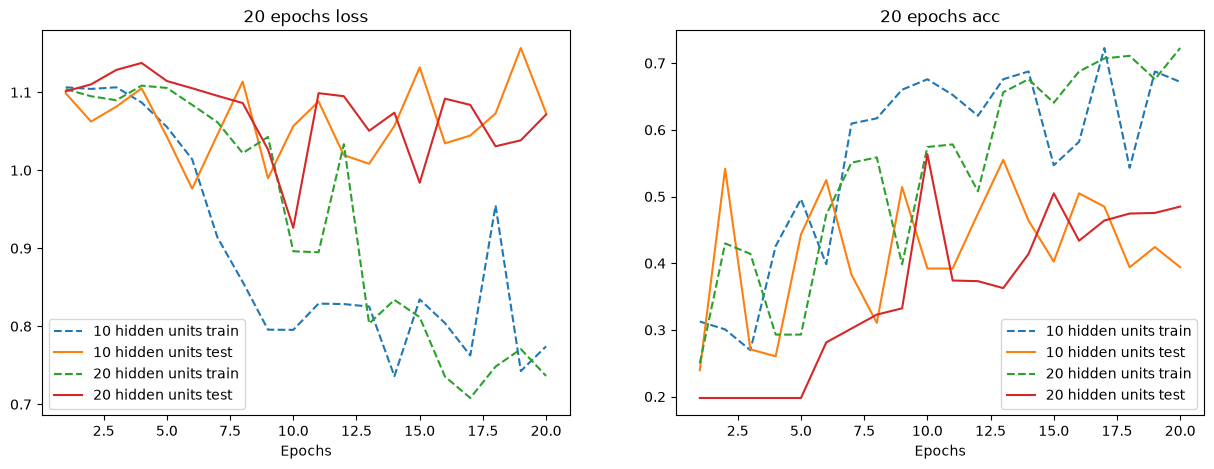

In [26]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_3 = TinyVGG(input_shape=3,
                  hidden_units=20,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_3.parameters(),
                             lr=0.001)

model_3_results = train(model=model_3,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=20)

plot_results({"10 hidden units": model_1_results,
              "20 hidden units": model_3_results}, title="20 epochs")

It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [27]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi 20% data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi 20% data...")
        zip_ref.extractall(image_path)

Did not find data\pizza_steak_sushi_20_percent directory, creating one...


Unzipping pizza, steak, sushi 20% data...


In [28]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\test'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\pizza'.
There are 0 directories and 58 images in 'data\pizza_steak_sushi_20_percent\test\steak'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\train'.
There are 0 directories and 154 images in 'data\pizza_steak_sushi_20_percent\train\pizza'.
There are 0 directories and 146 images in 'data\pizza_steak_sushi_20_percent\train\steak'.
There are 0 directories and 150 images in 'data\pizza_steak_sushi_20_percent\train\sushi'.


Excellent, we now have double the training and testing images... 

In [29]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

In [30]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((64, 64)),
  transforms.ToTensor()
])

# Create datasets
train_data_20_percent = ImageFolder(train_data_20_percent_path,
                                    transform=simple_transform)
test_data_20_percent = ImageFolder(test_data_20_percent_path,
                                   transform=simple_transform)

# Create dataloaders
train_dataloader_20_percent = DataLoader(train_data_20_percent,
                                         batch_size=32,
                                         num_workers=NUM_WORKERS,
                                         shuffle=True)
test_dataloader_20_percent = DataLoader(test_data_20_percent,
                                        batch_size=32,
                                        num_workers=NUM_WORKERS,
                                        shuffle=False)

len(train_data_20_percent), len(test_data_20_percent)

(450, 150)

  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:05<01:37,  5.13s/it]

Epoch: 1 | train_loss: 1.1012 | train_acc: 0.3396 | test_loss: 1.0950 | test_acc: 0.4222


 10%|█         | 2/20 [00:10<01:30,  5.02s/it]

Epoch: 2 | train_loss: 1.0995 | train_acc: 0.3479 | test_loss: 1.0655 | test_acc: 0.3744


...

 95%|█████████▌| 19/20 [01:35<00:05,  5.04s/it]

Epoch: 19 | train_loss: 0.6316 | train_acc: 0.7333 | test_loss: 0.9437 | test_acc: 0.5949


100%|██████████| 20/20 [01:39<00:00,  4.99s/it]

100%|██████████| 20/20 [01:39<00:00,  5.00s/it]

Epoch: 20 | train_loss: 0.5547 | train_acc: 0.7583 | test_loss: 1.0011 | test_acc: 0.5994


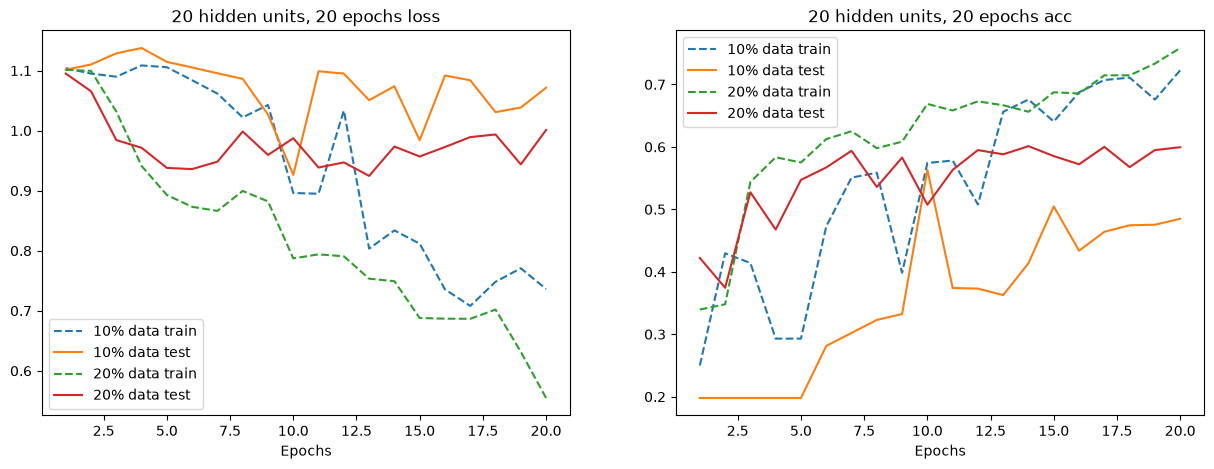

In [31]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_4 = TinyVGG(input_shape=3,
                  hidden_units=20,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_4.parameters(),
                             lr=0.001)

model_4_results = train(model=model_4,
                        train_dataloader=train_dataloader_20_percent,
                        test_dataloader=test_dataloader_20_percent,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=20)

plot_results({"10% data": model_3_results,
              "20% data": model_4_results}, title="20 hidden units, 20 epochs")

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction. 
* Does the model you trained in exercise 7 get it right? 
* If not, what do you think you could do to improve it?

In [32]:
# Use the pizza image that comes with the course repo (images/04-pizza-dad.jpeg)
import torchvision
from pathlib import Path

custom_image_path = Path("../../images/04-pizza-dad.jpeg")

# Read in custom image (uint8 values 0-255) and convert it to float values between 0 and 1
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.

# Resize it to the same size the model was trained on (64x64)
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])
custom_image_transformed = custom_image_transform(custom_image)
print(f"Original shape: {custom_image.shape}")
print(f"Transformed shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 4032, 3024])
Transformed shape: torch.Size([3, 64, 64])


Prediction probabilities: {'pizza': 0.7315002083778381, 'steak': 0.09765875339508057, 'sushi': 0.1708410382270813}

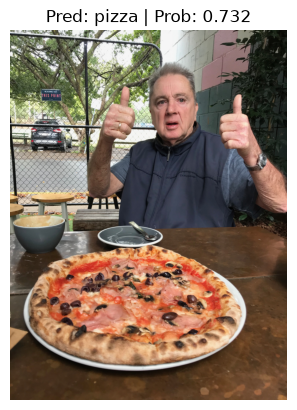

In [33]:
# Predict with the model trained on 20% data (exercise 7)
model_4.eval()
with torch.inference_mode():
  # Add a batch dimension: [3, 64, 64] -> [1, 3, 64, 64]
  custom_image_pred = model_4(custom_image_transformed.unsqueeze(dim=0).to(device))

custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1).cpu()
custom_image_pred_class = class_names[custom_image_pred_label]

plt.imshow(custom_image.permute(1, 2, 0))
plt.title(f"Pred: {custom_image_pred_class} | Prob: {custom_image_pred_probs.max().cpu():.3f}")
plt.axis(False)
print(f"Prediction probabilities: {dict(zip(class_names, custom_image_pred_probs.squeeze().cpu().tolist()))}")